## LinacBT + ATF2 Simulation in RF-Track

This notebook follows roughly the same flow as `Ext_ATF2.ipynb`:

1. Generate a LinacBT `.twiss` from the SAD lattice
2. Load it in RF-Track
3. Replace LinacBT monitors with `Screen` elements
4. Create a bunch from the LinacBT entrance Twiss
5. Track the bunch and inspect phase space, beam sizes, and pseudo-camera images

Note:
- The current SAD-to-TWISS conversion is already useful for RF-Track loading and monitor imaging.
- `COORD` and some SAD geometry details are still simplified, so this is a first working baseline rather than the final optics-faithful model.

In [ ]:
from pathlib import Path
import sys

import RF_Track as rft
import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd()
if not (project_root / 'Interfaces').exists():
    if (project_root.parent / 'Interfaces').exists():
        project_root = project_root.parent
    else:
        raise RuntimeError('Could not locate the project root containing Interfaces/.')

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from Interfaces.ATF2.Linac_ATF2.sad_to_twiss import ELECTRON_MASS_GEV, parse_sad_lattice, write_twiss_file
from Interfaces.ATF2.Linac_ATF2.linacbt_model import LinacBTSadModel


RF-Track, version 2.5.4

Copyright (C) 2016-2025 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.5 and fftw-3.3.5-sse2-avx



[RF-Track] Could not check for updates.


In [ ]:
beam_p_gev = 1.5
emit_n_m_rad = 5e-4  # gamma * epsilon from the note, with beta ~ 1
emit_n_mm_mrad = emit_n_m_rad * 1e6
beta_gamma = beam_p_gev / ELECTRON_MASS_GEV
emit_geom_m_rad = emit_n_m_rad / beta_gamma
twiss_tag = '1p5GeV'

print(f'Beam momentum for this notebook: {beam_p_gev:.6f} GeV/c')
print(f'beta*gamma = {beta_gamma:.3f}')
print(f'Normalized emittance for RF-Track: {emit_n_mm_mrad:.3f} mm.mrad')
print(f'Geometric emittance at this energy: {emit_geom_m_rad:.6e} m.rad')

### Generate the lattice `.twiss`

In [ ]:
sad_path = project_root / 'Interfaces/ATF2/Linac_ATF2/atfbt199912_daihon.sad'
template_twiss_path = project_root / 'Interfaces/ATF2/Linac_ATF2/linacend.tws'
twiss_path = project_root / f'Interfaces/ATF2/Linac_ATF2/atfbt199912_daihon_{twiss_tag}.twiss'

lattice_data = parse_sad_lattice(
    sad_path=sad_path,
    line_name='bt',
    output_energy_gev=beam_p_gev,
)

write_twiss_file(
    output_path=twiss_path,
    lattice=lattice_data,
    output_energy_gev=beam_p_gev,
    template_path=template_twiss_path,
)

energy_scale = beam_p_gev / lattice_data.momentum_gev
monitor_names = [record.name for record in lattice_data.records if record.keyword == 'MONITOR']

print(f'TWISS written to: {twiss_path}')
print(f'Original SAD momentum: {lattice_data.momentum_gev:.6f} GeV/c')
print(f'Hardware current scale for {beam_p_gev:.3f} GeV: {energy_scale:.6f}')
print(f'Number of monitors/screens: {len(monitor_names)}')
print(monitor_names)

TWISS written to: /home/motokisato/Projects/MLflight-simulator/Interfaces/ATF2/Linac_ATF2/atfbt199912_daihon_1p542GeV.twiss
Original SAD momentum: 1.542282 GeV/c
Hardware current scale for 1.542 GeV: 0.999817
Number of monitors/screens: 26
['MS1T', 'ML1T', 'MB1T', 'ML2T', 'ML101T', 'ML102T', 'MS2T', 'ML103T', 'ML3T', 'ML104T', 'ML4T', 'ML105T', 'ML5T', 'MW1T', 'MT1T', 'MS3T', 'MW3T', 'ML6T', 'MW4T', 'ML106T', 'ML7T', 'MS4T', 'ML8T', 'ML9T', 'ML10T', 'ML11T']


### Load the lattice

In [ ]:
BT_ATF2 = rft.Lattice(str(twiss_path))

for name in monitor_names:
    screen = rft.Screen()
    screen.set_name(name)
    BT_ATF2[name].replace_with(screen)

screen_names = [screen.get_name() for screen in BT_ATF2.get_screens()]
screen_names

['MS1T',
 'ML1T',
 'MB1T',
 'ML2T',
 'ML101T',
 'ML102T',
 'MS2T',
 'ML103T',
 'ML3T',
 'ML104T',
 'ML4T',
 'ML105T',
 'ML5T',
 'MW1T',
 'MT1T',
 'MS3T',
 'MW3T',
 'ML6T',
 'MW4T',
 'ML106T',
 'ML7T',
 'MS4T',
 'ML8T',
 'ML9T',
 'ML10T',
 'ML11T']

### Create the bunch

In [ ]:
model = LinacBTSadModel(
    sad_path=sad_path,
    energy_gev=beam_p_gev,
    emit_x_n_mm_mrad=emit_n_mm_mrad,
    emit_y_n_mm_mrad=emit_n_mm_mrad,
)
initial = model.initial_twiss

Pref = beam_p_gev * 1e3
population = 2e10

BT_twiss = rft.Bunch6d_twiss()
BT_twiss.emitt_x = model.emit_x_n_mm_mrad
BT_twiss.emitt_y = model.emit_y_n_mm_mrad
BT_twiss.beta_x = initial.betx
BT_twiss.beta_y = initial.bety
BT_twiss.alpha_x = initial.alfx
BT_twiss.alpha_y = initial.alfy
if hasattr(BT_twiss, 'disp_x'):
    BT_twiss.disp_x = initial.dx
if hasattr(BT_twiss, 'disp_px'):
    BT_twiss.disp_px = initial.dpx
BT_twiss.sigma_t = model.sigma_t_mm
BT_twiss.sigma_pt = model.sigma_pt_permille

Nparticles = 10000
B0 = rft.Bunch6d_QR(rft.electronmass, population, -1, Pref, BT_twiss, Nparticles)

print('Initial Twiss at IPXT:')
print(f'  betx = {initial.betx:.6f} m, alfx = {initial.alfx:.6f}')
print(f'  bety = {initial.bety:.6f} m, alfy = {initial.alfy:.6f}')
print(f'  RF-Track emittance input = {model.emit_x_n_mm_mrad:.3f} mm.mrad')
print(f'  Geometric emittance used by the linear model = {model.emit_x_geom_m_rad:.6e} m.rad')
print(f'  sigma_pt = {model.sigma_pt_permille:.3f} permille')

Initial Twiss at IPXT:
  betx = 4.218220 m, alfx = 7.135536
  bety = 6.166945 m, alfy = -4.806601


### Perform tracking

In [ ]:
B1 = BT_ATF2.track(B0)

### Make plots
#### Initial beam

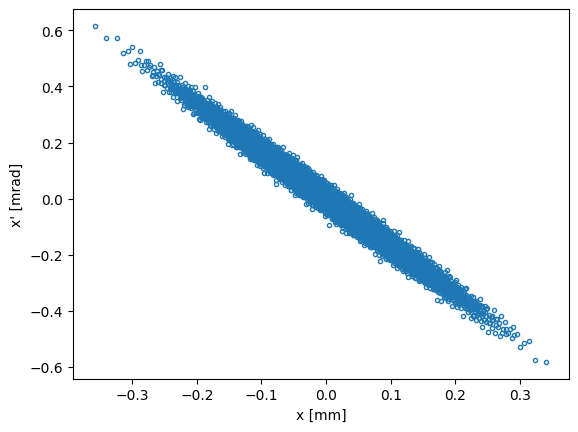

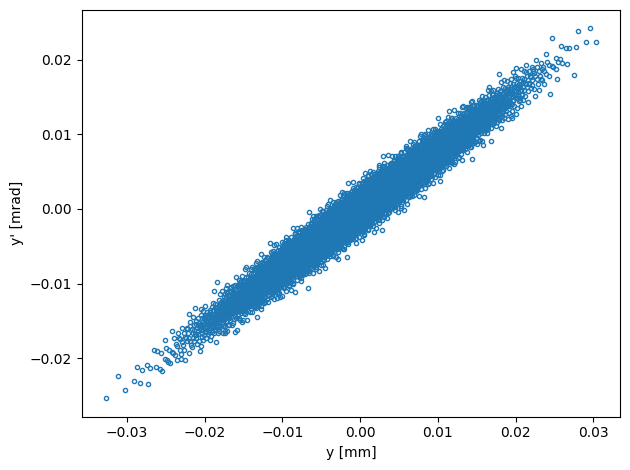

In [ ]:
M0 = B0.get_phase_space()

plt.figure()
plt.plot(M0[:, 0], M0[:, 1], '.', mfc='none')
plt.xlabel('x [mm]')
plt.ylabel("x' [mrad]")

plt.figure()
plt.plot(M0[:, 2], M0[:, 3], '.', mfc='none')
plt.xlabel('y [mm]')
plt.ylabel("y' [mrad]")
plt.tight_layout()

#### Example screen

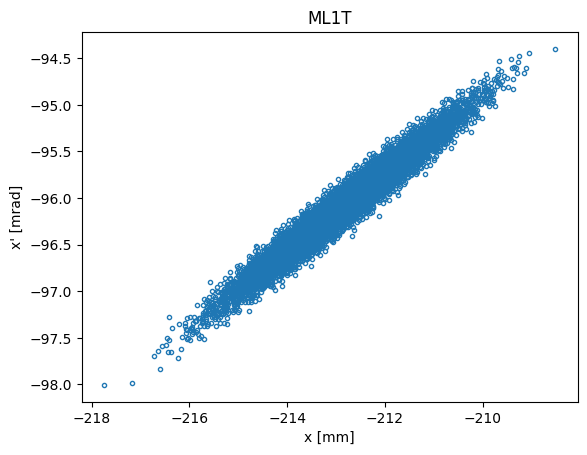

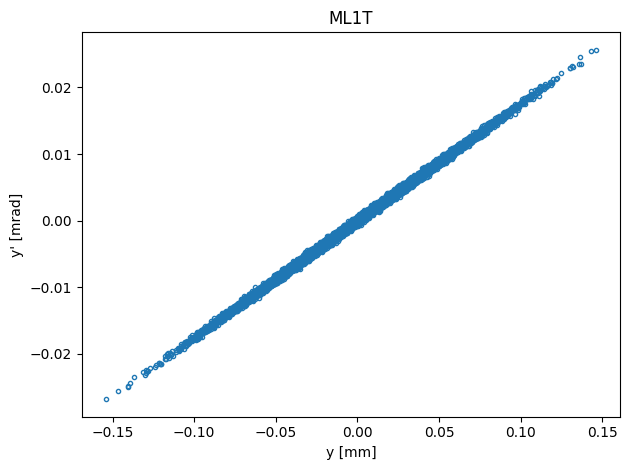

In [ ]:
monitor_name = 'ML1T' if 'ML1T' in screen_names else screen_names[0]
B1_monitor = BT_ATF2[monitor_name].get_bunch()
M1 = B1_monitor.get_phase_space('%x %xp %y %yp %dt %P')

plt.figure()
plt.plot(M1[:, 0], M1[:, 1], '.', mfc='none')
plt.xlabel('x [mm]')
plt.ylabel("x' [mrad]")
plt.title(monitor_name)

plt.figure()
plt.plot(M1[:, 2], M1[:, 3], '.', mfc='none')
plt.xlabel('y [mm]')
plt.ylabel("y' [mrad]")
plt.title(monitor_name)
plt.tight_layout()

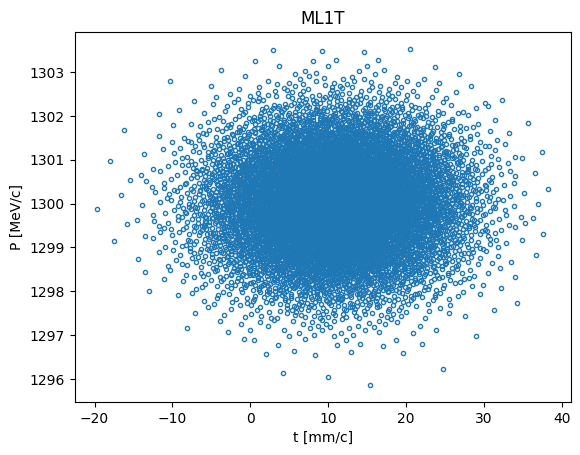

In [ ]:
plt.figure()
plt.plot(M1[:, 4], M1[:, 5], '.', mfc='none')
plt.xlabel('t [mm/c]')
plt.ylabel('P [MeV/c]')
plt.title(monitor_name)
plt.show()

#### Beam size and dispersion along the line

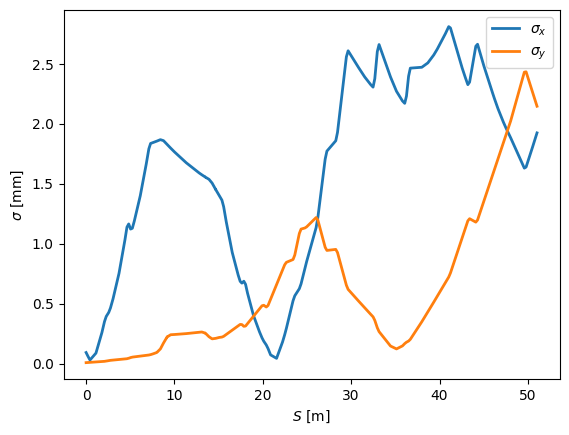

In [ ]:
T = BT_ATF2.get_transport_table('%S %sigma_x %sigma_y')
plt.plot(T[:, 0], T[:, 1], linewidth=2, label=r'$\sigma_x$')
plt.plot(T[:, 0], T[:, 2], linewidth=2, label=r'$\sigma_y$')
plt.legend()
plt.xlabel('$S$ [m]')
plt.ylabel(r'$\sigma$ [mm]')
plt.show()

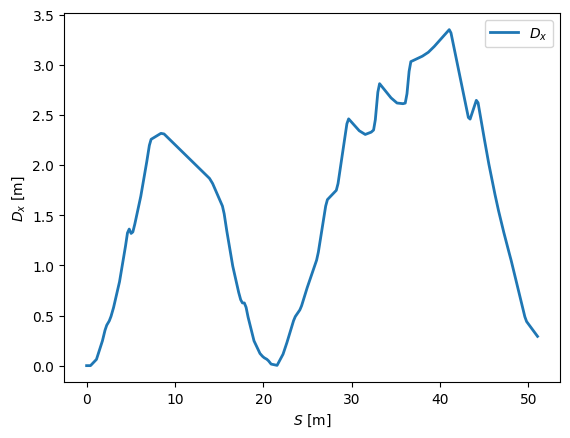

In [ ]:
T = BT_ATF2.get_transport_table('%S %disp_x')
plt.plot(T[:, 0], T[:, 1], linewidth=2, label=r'$D_x$')
plt.legend()
plt.xlabel('$S$ [m]')
plt.ylabel(r'$D_x$ [m]')
plt.show()

### Pseudo-camera images at several monitors

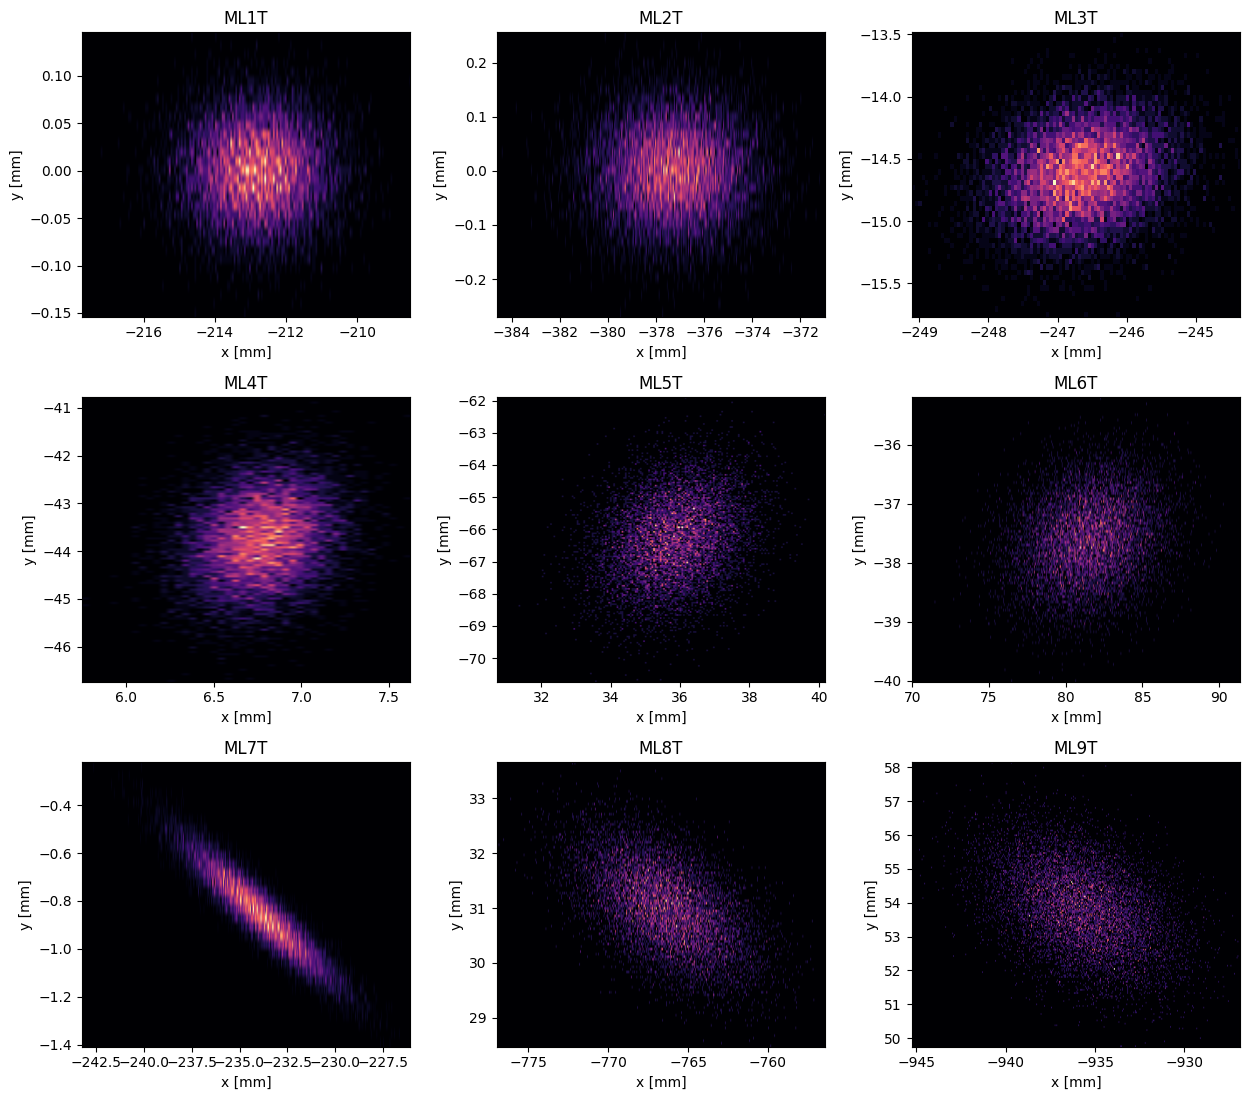

In [ ]:
selected_monitors = [
    name for name in ['ML1T', 'ML2T', 'ML3T', 'ML4T', 'ML5T', 'ML6T', 'ML7T', 'ML8T', 'ML9T']
    if name in screen_names
]
if not selected_monitors:
    selected_monitors = screen_names[:9]

pixel_size_mm = 0.05
ncols = 3
nrows = int(np.ceil(len(selected_monitors) / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4.2 * ncols, 3.7 * nrows), squeeze=False)

for ax in axes.ravel():
    ax.axis('off')

for ax, name in zip(axes.ravel(), selected_monitors):
    ax.axis('on')
    Mxy = BT_ATF2[name].get_bunch().get_phase_space('%x %y')
    nx = max(32, int(np.ceil(max(np.ptp(Mxy[:, 0]), pixel_size_mm) / pixel_size_mm)) + 8)
    ny = max(32, int(np.ceil(max(np.ptp(Mxy[:, 1]), pixel_size_mm) / pixel_size_mm)) + 8)
    image, xedges, yedges = np.histogram2d(Mxy[:, 0], Mxy[:, 1], bins=(nx, ny))
    ax.imshow(
        image.T,
        origin='lower',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        aspect='auto',
        cmap='magma',
    )
    ax.set_title(name)
    ax.set_xlabel('x [mm]')
    ax.set_ylabel('y [mm]')

fig.tight_layout()